# Week 07 consolidated Bayesian optimisation notebook

This notebook presents Functions 1–8 in one systematic analytical record. Every function follows the same eleven-stage sequence below. UCB results are unevaluated proposals and are never appended as returned observations.

**Evidence used:** starter observations plus immutable-ledger returns through Week 06.

## Table of contents

1. Create week's_dataset by appending the previous output results
2. Extract the function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

# Function 1

Function 1 uses the verified evidence available before Week 07.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 7, 1, 2, 6
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [2]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
6,starter,0.312691,0.078723,-2.089093e-91
7,starter,0.683418,0.861057,2.535001e-40
8,starter,0.082507,0.403488,3.606771e-81
9,starter,0.883890,0.582254,6.229856e-48
10,week_01,0.374540,0.950714,-1.560647e-117
11,week_02,0.536429,0.835362,1.674933e-36
12,week_03,0.614168,0.334143,-1.075594e-32
13,week_04,0.872626,0.321598,-2.466641e-107
14,week_05,0.897714,0.081699,7.651210e-239


## 2. Extract the function

In [3]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 1: 2 input dimensions, 16 verified observations


## 3. Check shapes and missing values

In [4]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(16, 2)"
1,output shape,"(16,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [5]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,16.0,0.562885,0.254186,0.082507,3.607560e-01,5.942486e-01,7.583561e-01,8.977140e-01
x2,16.0,0.557399,0.321567,0.078723,3.073814e-01,6.318902e-01,8.417859e-01,9.996730e-01
output,16.0,-0.000225,0.000902,-0.003606,-5.222733e-92,1.670886e-124,3.049935e-47,7.710875e-16


## 5. Plot the output trend

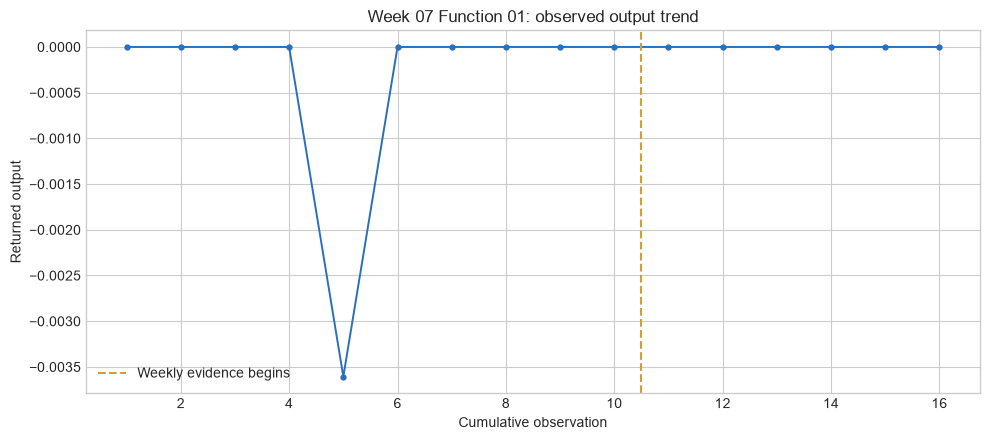

In [6]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

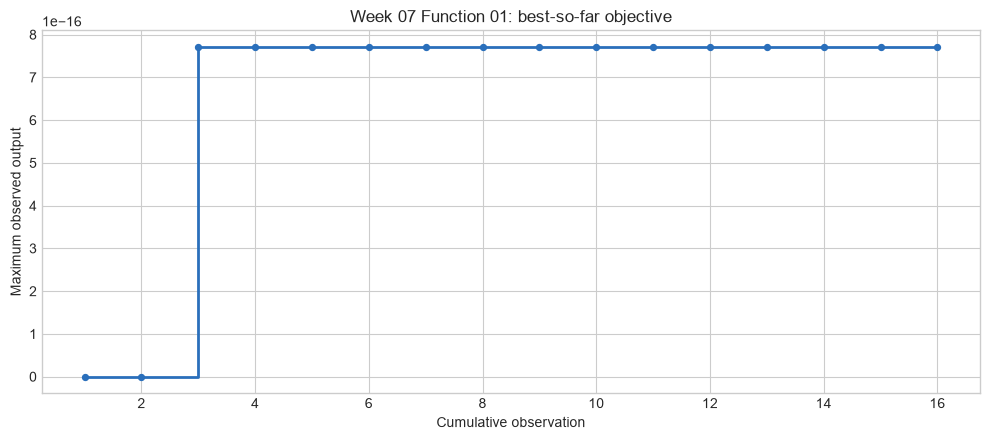

In [7]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [8]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,3,starter,0.731024,0.733,7.710875e-16


## 8. Plot the correlation heatmap

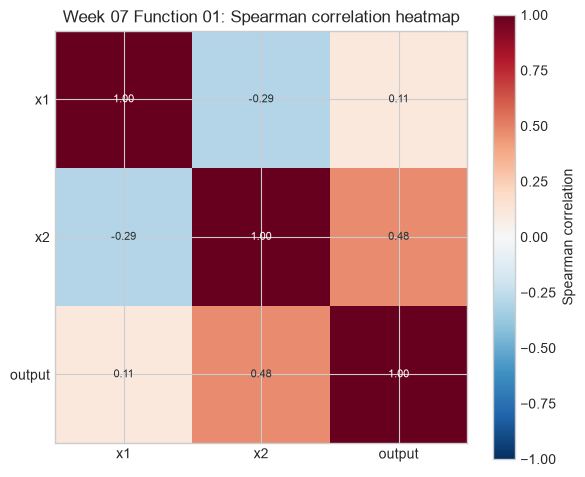

In [9]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

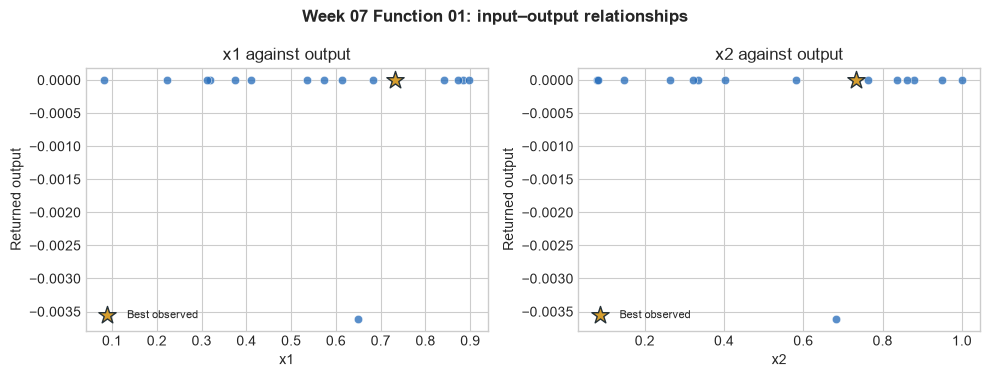

In [10]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [11]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.08**2 * Matern(length_scale=[10, 0.037], nu=2.5) + WhiteKernel(noise_level=9.7e-08)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [12]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_1:0.681236-0.513351


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,7,1,2.0,0.681236,0.513351,-0.000158,0.000925,0.001693,proposed_not_evaluated


# Function 2

Function 2 uses the verified evidence available before Week 07.

In [13]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 7, 2, 2, 6
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [14]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
6,starter,0.438166,0.685018,0.244619
7,starter,0.341750,0.028698,0.038749
8,starter,0.338648,0.213867,-0.013858
9,starter,0.702637,0.926564,0.611205
10,week_01,0.374540,0.950714,-0.031830
11,week_02,0.978752,0.932731,0.022667
12,week_03,0.000006,0.334143,0.048684
13,week_04,0.197553,0.808683,0.038775
14,week_05,0.555332,0.360931,0.220781


## 2. Extract the function

In [15]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 2: 2 input dimensions, 16 verified observations


## 3. Check shapes and missing values

In [16]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(16, 2)"
1,output shape,"(16,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [17]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,16.0,0.497779,0.272185,0.000006,0.340974,0.463899,0.675009,0.978752
x2,16.0,0.576075,0.323269,0.028698,0.323221,0.698069,0.838153,0.950714
output,16.0,0.172897,0.206820,-0.065624,0.022996,0.104608,0.256963,0.611205


## 5. Plot the output trend

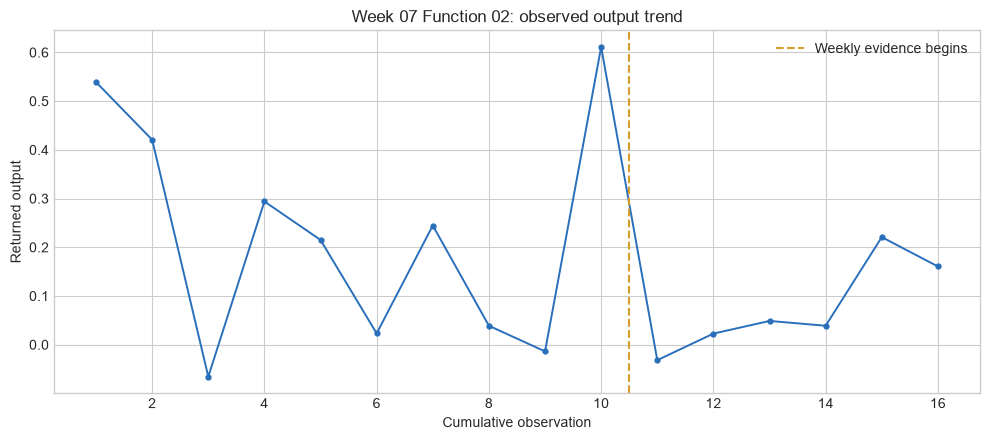

In [18]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

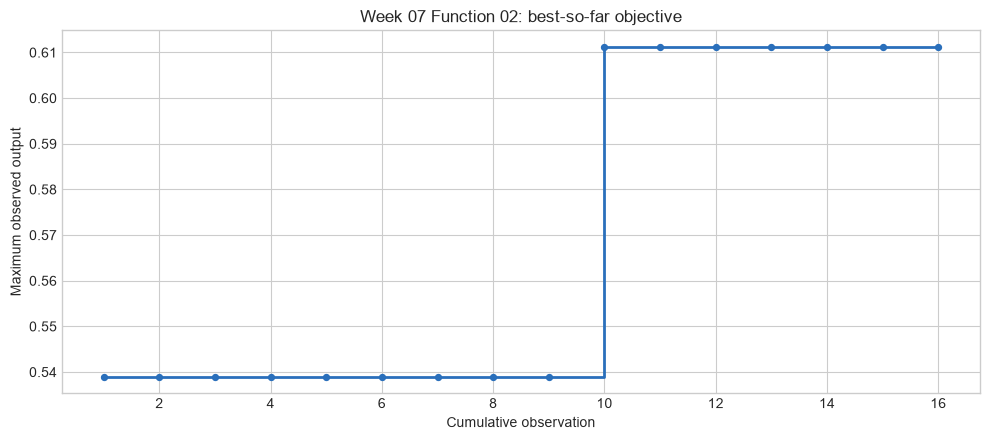

In [19]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [20]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,10,starter,0.702637,0.926564,0.611205


## 8. Plot the correlation heatmap

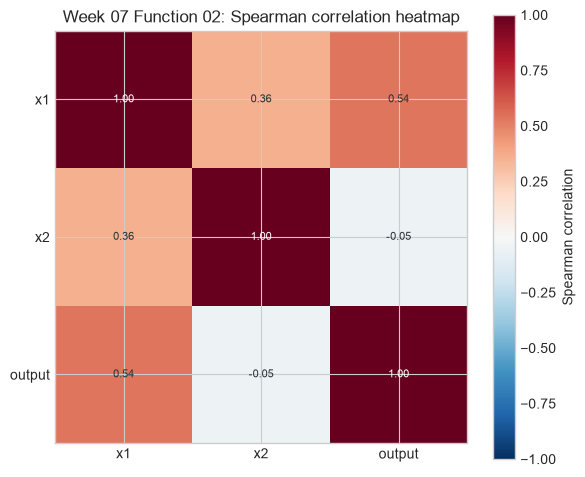

In [21]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

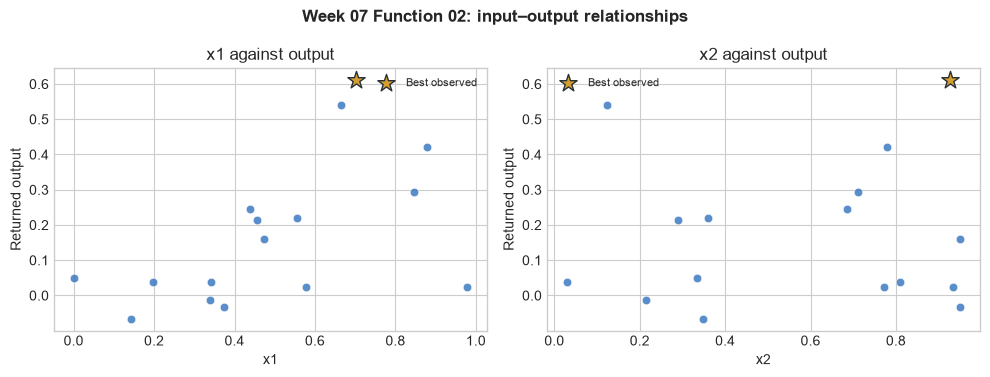

In [22]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [23]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.01**2 * Matern(length_scale=[0.0457, 1.36], nu=2.5) + WhiteKernel(noise_level=1.07e-06)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [24]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_2:0.703819-0.060425


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,7,2,2.0,0.703819,0.060425,0.554235,0.122458,0.799152,proposed_not_evaluated


# Function 3

Function 3 uses the verified evidence available before Week 07.

In [25]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 7, 3, 3, 6
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [26]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,output
observation,,,,,
11,starter,0.666014,0.671985,0.246295,-0.105965
12,starter,0.046809,0.231360,0.770618,-0.118048
13,starter,0.600097,0.725136,0.066089,-0.036378
14,starter,0.965995,0.861120,0.566829,-0.056758
15,week_01,0.444444,0.666666,0.333333,-0.040908
16,week_02,0.657452,0.998464,0.817253,-0.089875
17,week_03,0.670026,0.057881,0.658241,-0.183239
18,week_04,0.650132,0.218327,0.110542,-0.082513
19,week_05,0.522711,0.090769,0.451242,-0.057397


## 2. Extract the function

In [27]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 3: 3 input dimensions, 21 verified observations


## 3. Check shapes and missing values

In [28]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(21, 3)"
1,output shape,"(21,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [29]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,21.0,0.452334,0.247175,0.046809,0.220549,0.492581,0.650132,0.965995
x2,21.0,0.486565,0.272529,0.057881,0.284196,0.420613,0.671985,0.998464
x3,21.0,0.433707,0.276178,0.066089,0.246295,0.340176,0.658241,0.990882
output,21.0,-0.103735,0.077392,-0.398926,-0.113869,-0.094190,-0.056758,-0.034835


## 5. Plot the output trend

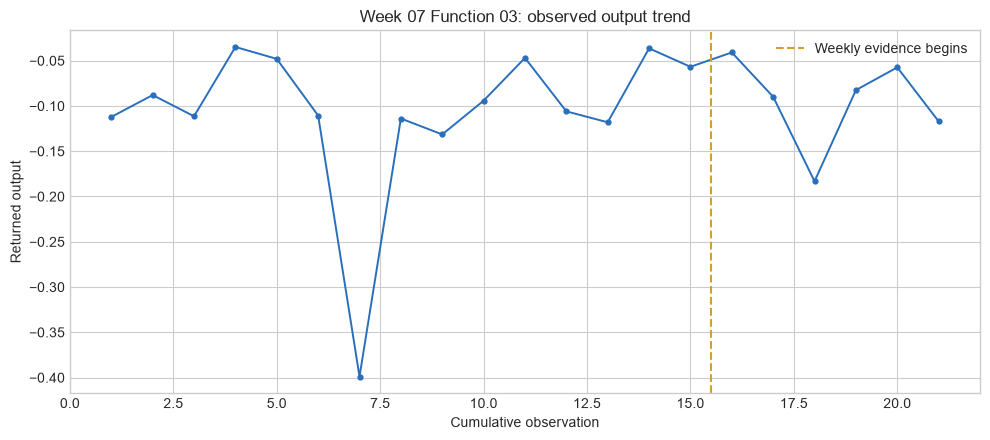

In [30]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

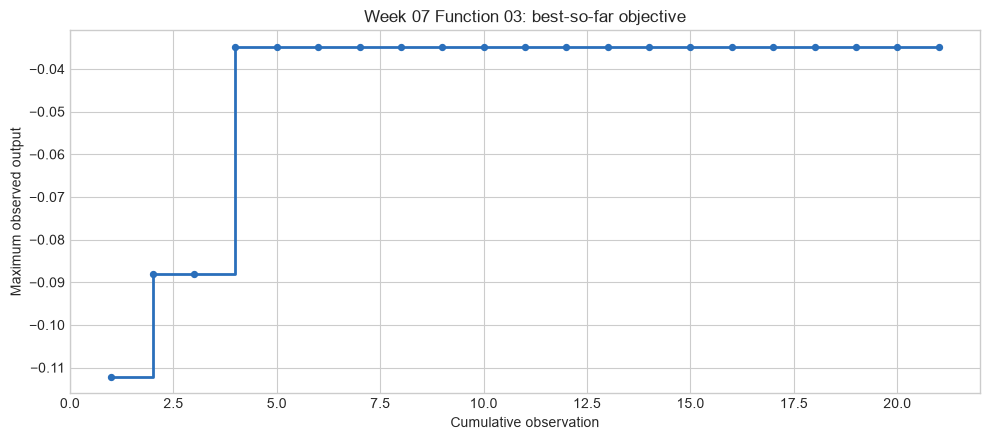

In [31]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [32]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,output
0,4,starter,0.492581,0.611593,0.340176,-0.034835


## 8. Plot the correlation heatmap

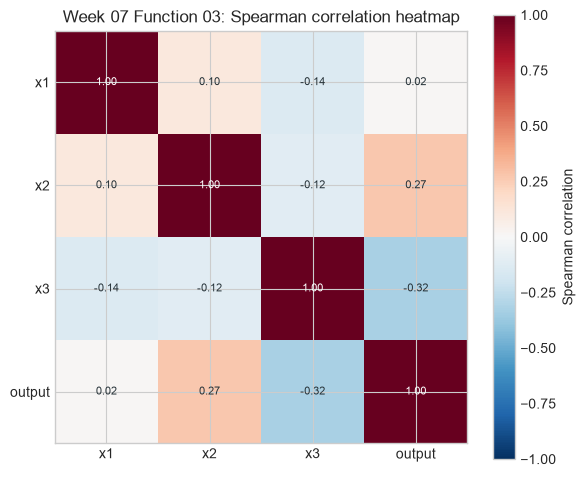

In [33]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

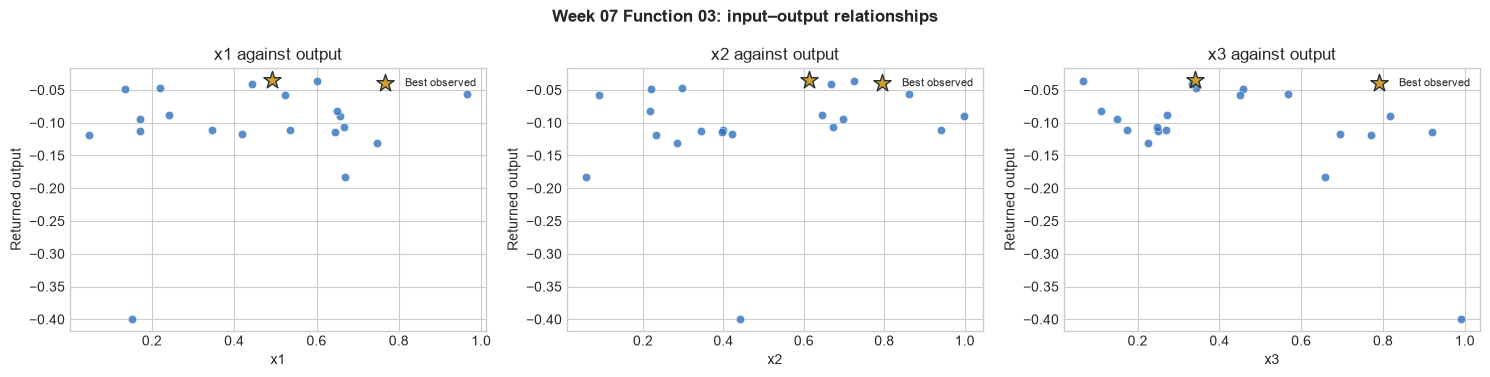

In [34]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [35]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.59**2 * Matern(length_scale=[10, 1.51, 0.11], nu=2.5) + WhiteKernel(noise_level=1e-06)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [36]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_3:0.183130-0.036144-0.001721


,week,function,kappa,x1,x2,x3,predicted_mean,predicted_std,ucb_score,status
0,7,3,2.0,0.18313,0.036144,0.001721,-0.051507,0.082894,0.114281,proposed_not_evaluated


# Function 4

Function 4 uses the verified evidence available before Week 07.

In [37]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 7, 4, 4, 6
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [38]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
26,starter,0.664955,0.046566,0.116777,0.793718,-19.989498
27,starter,0.577766,0.428772,0.425826,0.249007,-4.025542
28,starter,0.738613,0.482103,0.709366,0.503970,-13.122782
29,starter,0.854811,0.493965,0.735310,0.808092,-23.139428
30,week_01,0.555555,0.444444,0.222222,0.111111,-8.727516
31,week_02,0.006280,0.281840,0.932013,0.960202,-31.735358
32,week_03,0.394519,0.361122,0.256803,0.461856,-1.981075
33,week_04,0.715715,0.504442,0.275065,0.552962,-9.312812
34,week_05,0.713766,0.198601,0.014095,0.068347,-17.926307


## 2. Extract the function

In [39]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 4: 4 input dimensions, 36 verified observations


## 3. Check shapes and missing values

In [40]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(36, 4)"
1,output shape,"(36,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [41]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,36.0,0.539595,0.288835,0.006280,0.274340,0.601918,0.748382,0.985622
x2,36.0,0.459615,0.287279,0.006250,0.190472,0.488034,0.681607,0.919592
x3,36.0,0.461487,0.281439,0.014095,0.220976,0.432316,0.715852,0.942545
x4,36.0,0.468534,0.293639,0.068347,0.203700,0.492389,0.735386,0.999483
output,36.0,-16.881113,7.680952,-32.625660,-21.186594,-16.040082,-12.436247,-1.981075


## 5. Plot the output trend

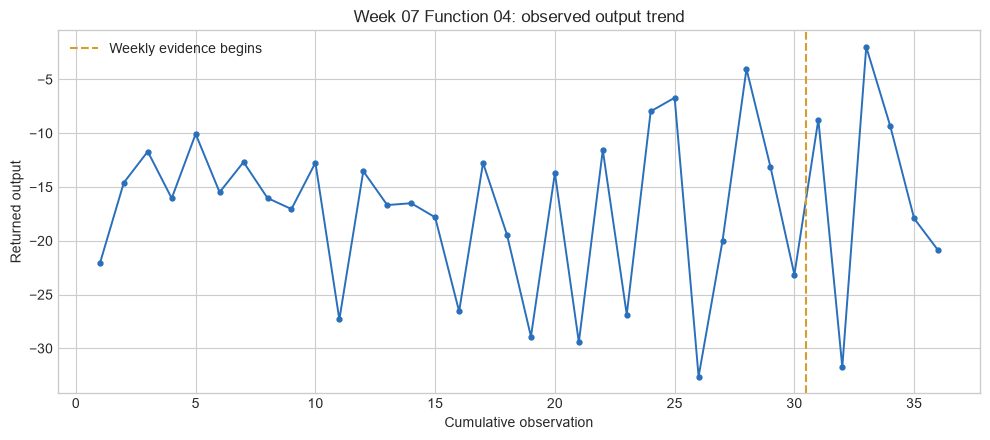

In [42]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

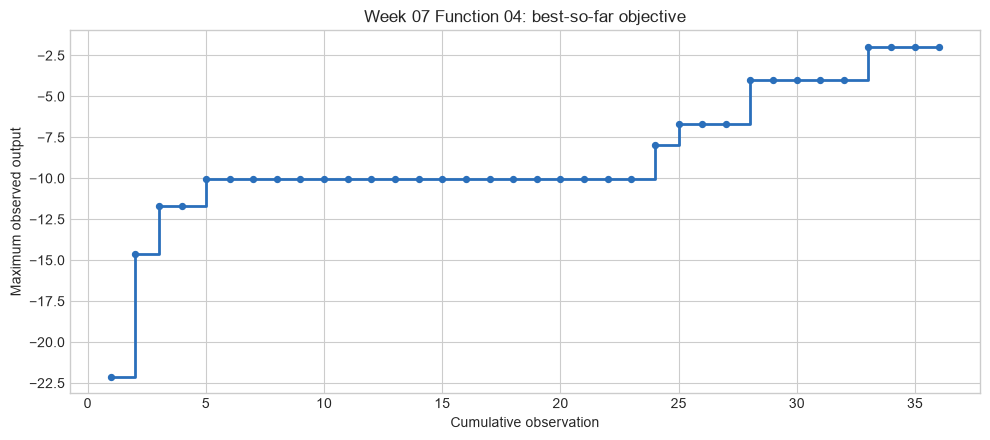

In [43]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [44]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,33,week_03,0.394519,0.361122,0.256803,0.461856,-1.981075


## 8. Plot the correlation heatmap

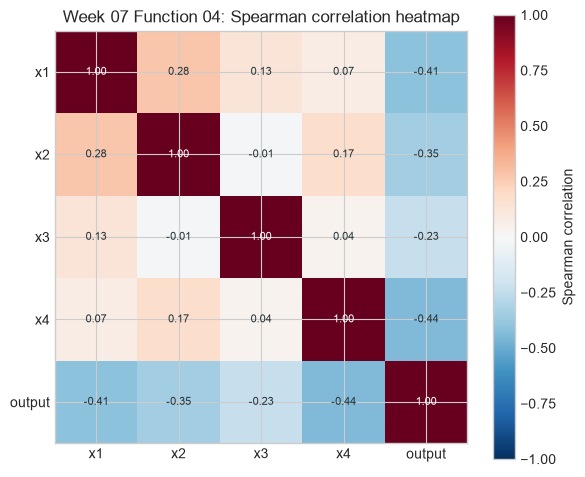

In [45]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

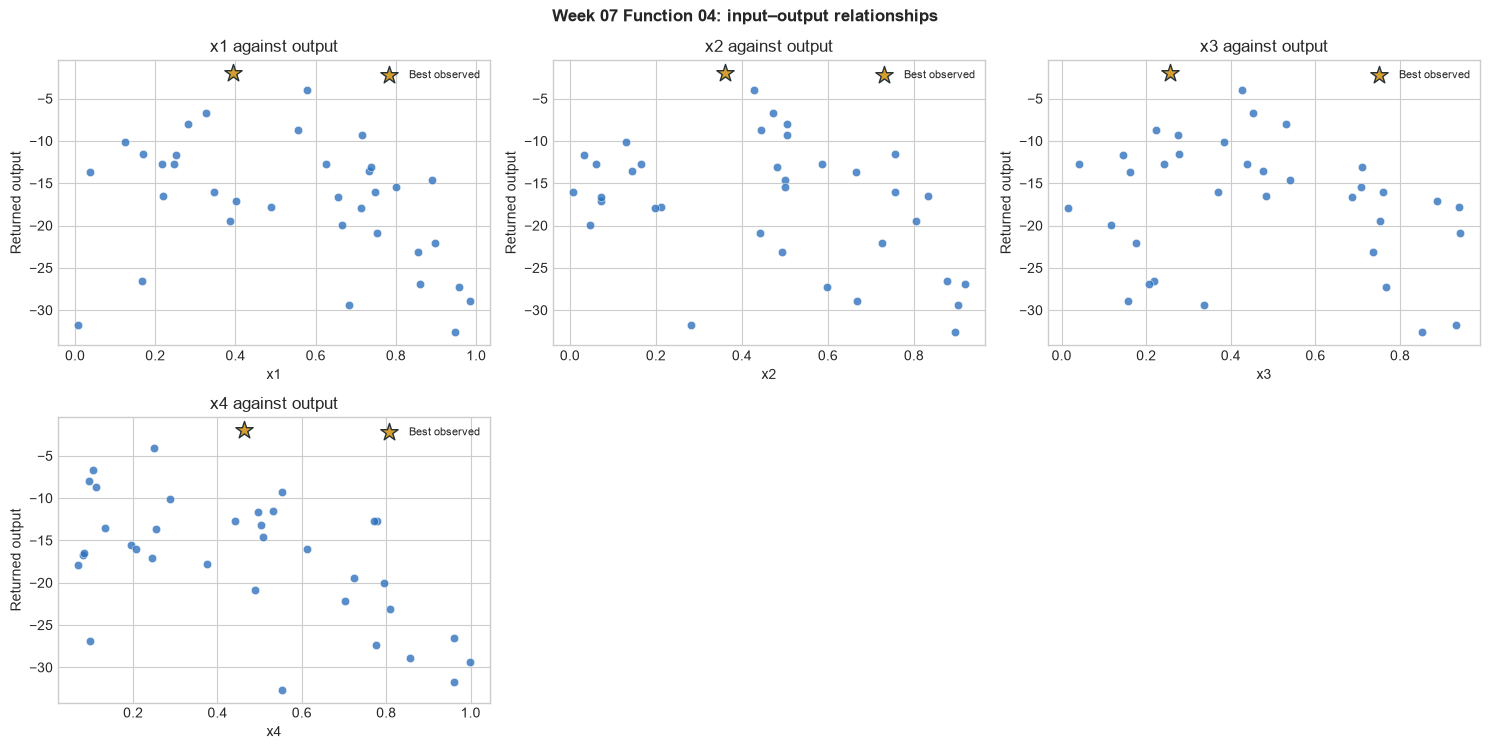

In [46]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [47]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 4.79**2 * Matern(length_scale=[2, 1.97, 2.08, 2.08], nu=2.5) + WhiteKernel(noise_level=0.00139)
Training R²: 0.9999


## 11. Apply UCB to generate the next query point

In [48]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_4:0.432849-0.380633-0.430551-0.476967


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,7,4,2.0,0.432849,0.380633,0.430551,0.476967,-1.690877,0.58174,-0.527398,proposed_not_evaluated


# Function 5

Function 5 uses the verified evidence available before Week 07.

In [49]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 7, 5, 4, 6
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [50]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
16,starter,0.725262,0.479870,0.088947,0.759760,28.866752
17,starter,0.355482,0.639619,0.417618,0.122604,45.181570
18,starter,0.119879,0.862540,0.643331,0.849804,431.612757
19,starter,0.126885,0.153430,0.770162,0.190518,9.972332
20,week_01,0.224189,0.846480,0.879484,0.878515,1088.853511
21,week_02,0.255841,0.841692,0.888984,0.860260,1035.634146
22,week_03,0.255842,0.841692,0.888985,0.860266,1035.664748
23,week_04,0.000000,0.000000,0.000000,0.000000,163.122500
24,week_05,0.754614,0.504566,0.432986,0.307039,0.940116


## 2. Extract the function

In [51]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 5: 4 input dimensions, 26 verified observations


## 3. Check shapes and missing values

In [52]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(26, 4)"
1,output shape,"(26,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [53]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,26.0,0.436662,0.240171,0.00000,0.232102,0.438642,0.671864,0.836478
x2,26.0,0.523402,0.284425,0.00000,0.318219,0.569706,0.796778,0.862540
x3,26.0,0.521085,0.283948,0.00000,0.329879,0.543505,0.759799,0.898891
x4,26.0,0.515003,0.316266,0.00000,0.219648,0.477600,0.841070,0.957644
output,26.0,255.060158,369.279978,0.11294,25.534004,71.438914,276.026311,1088.859618


## 5. Plot the output trend

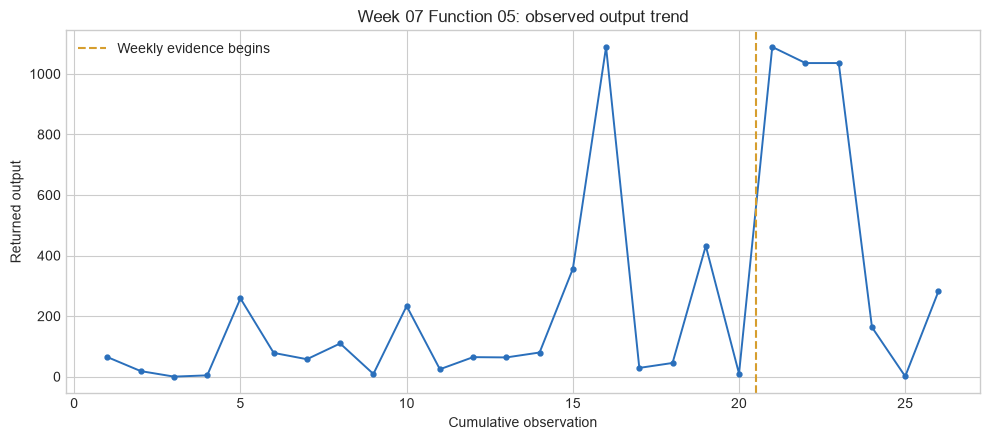

In [54]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

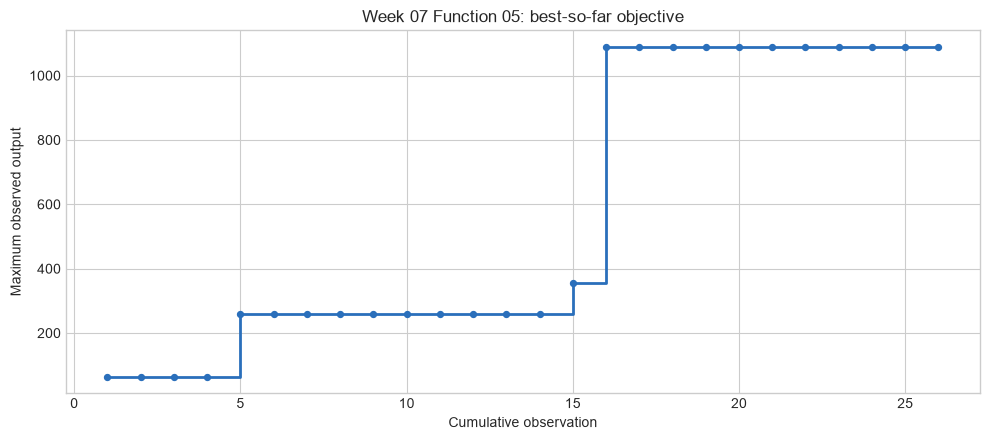

In [55]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [56]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,16,starter,0.224189,0.84648,0.879484,0.878516,1088.859618


## 8. Plot the correlation heatmap

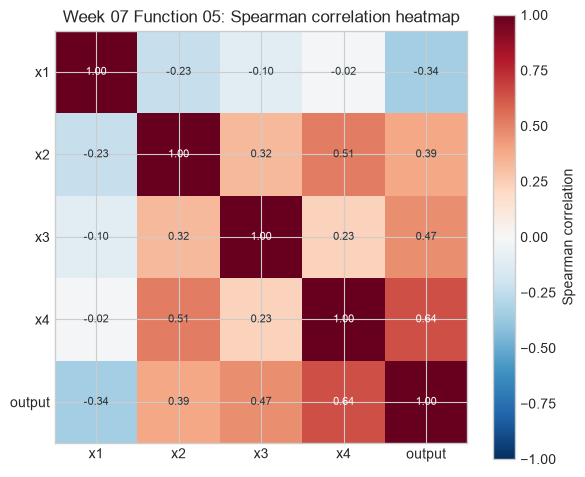

In [57]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

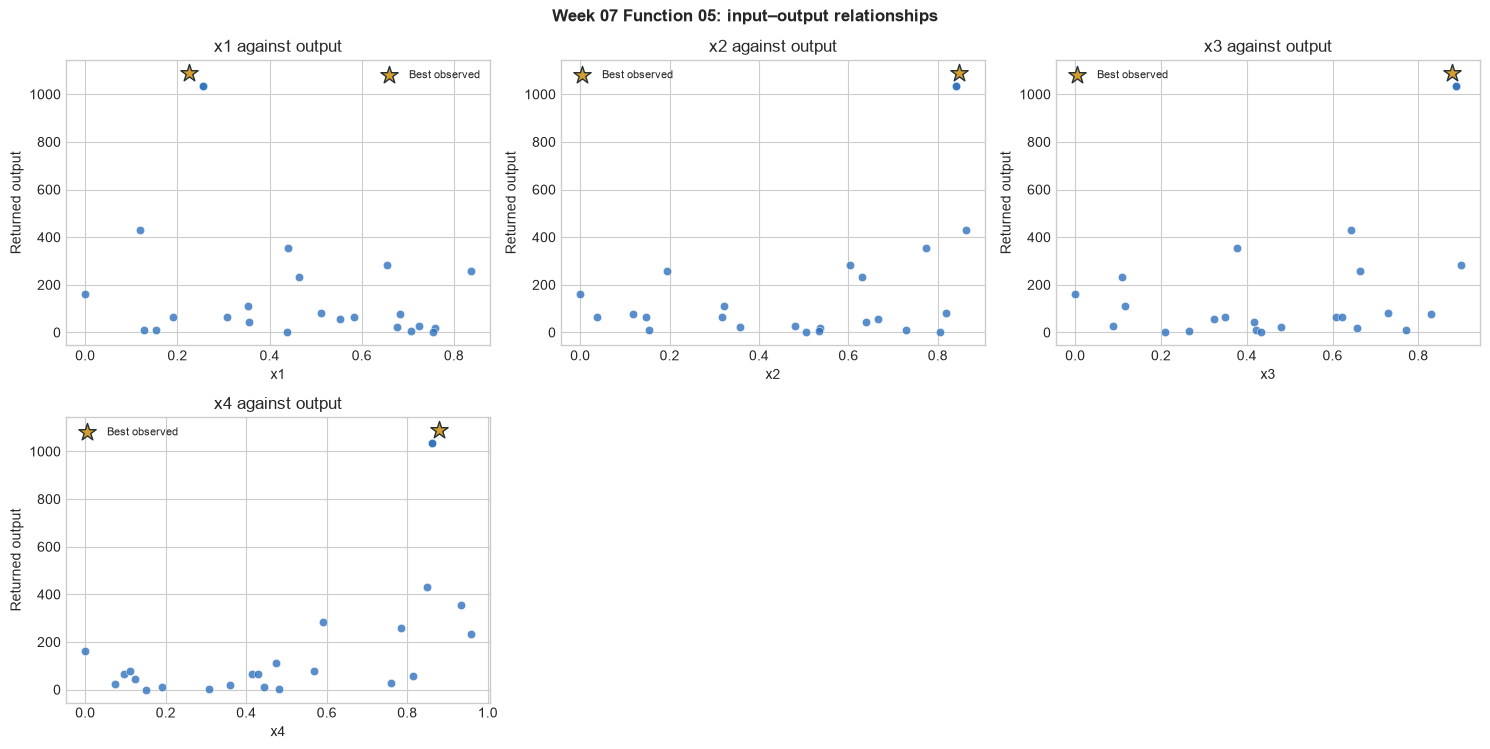

In [58]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [59]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 2.63**2 * Matern(length_scale=[10, 5.11, 1.14, 0.733], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [60]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_5:0.233883-0.196757-0.998400-0.983248


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,7,5,2.0,0.233883,0.196757,0.9984,0.983248,1664.152642,134.097587,1932.347815,proposed_not_evaluated


# Function 6

Function 6 uses the verified evidence available before Week 07.

In [61]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 7, 6, 5, 6
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [62]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,output
observation,,,,,,,
16,starter,0.432166,0.715618,0.341819,0.705000,0.614962,-1.294247
17,starter,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757
18,starter,0.921776,0.931871,0.414876,0.595057,0.735626,-2.155768
19,starter,0.126679,0.291470,0.064528,0.680515,0.892819,-1.746882
20,week_01,0.728186,0.154693,0.732552,0.693997,0.564013,-1.152035
21,week_02,0.433654,0.486678,0.282753,0.972905,0.323321,-0.878241
22,week_03,0.495070,0.097152,0.672921,0.000007,0.351268,-1.339542
23,week_04,0.973181,0.022807,0.714484,0.145453,0.974790,-2.437508
24,week_05,0.824244,0.022732,0.960907,0.041715,0.897560,-2.529369


## 2. Extract the function

In [63]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 6: 5 input dimensions, 26 verified observations


## 3. Check shapes and missing values

In [64]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(26, 5)"
1,output shape,"(26,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [65]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,26.0,0.584285,0.287777,0.021735,0.432538,0.678747,0.782602,0.973181
x2,26.0,0.470290,0.310850,0.022732,0.202974,0.391958,0.782285,0.931871
x3,26.0,0.519758,0.308753,0.016523,0.297520,0.609962,0.732552,0.978806
x4,26.0,0.509172,0.309786,0.000007,0.209156,0.621691,0.702683,0.972905
x5,26.0,0.467377,0.297463,0.004911,0.245591,0.516805,0.657031,0.974790
output,26.0,-1.521424,0.510983,-2.571170,-1.735801,-1.348112,-1.215913,-0.714265


## 5. Plot the output trend

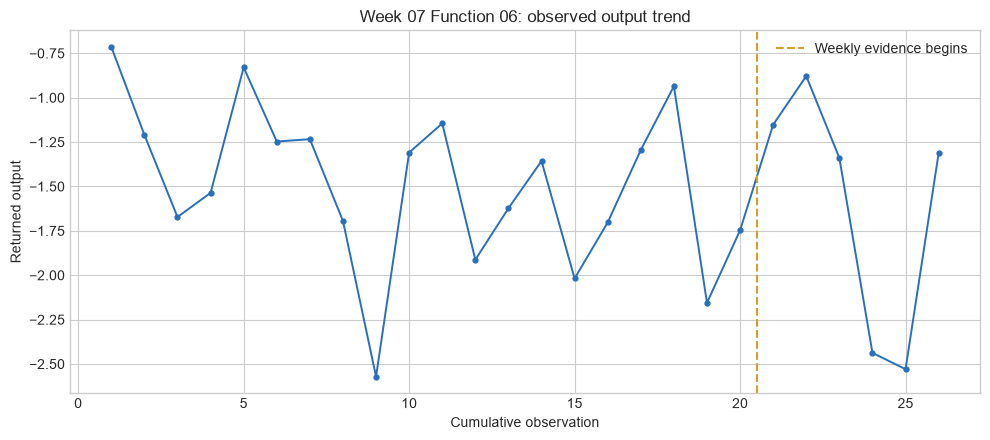

In [66]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

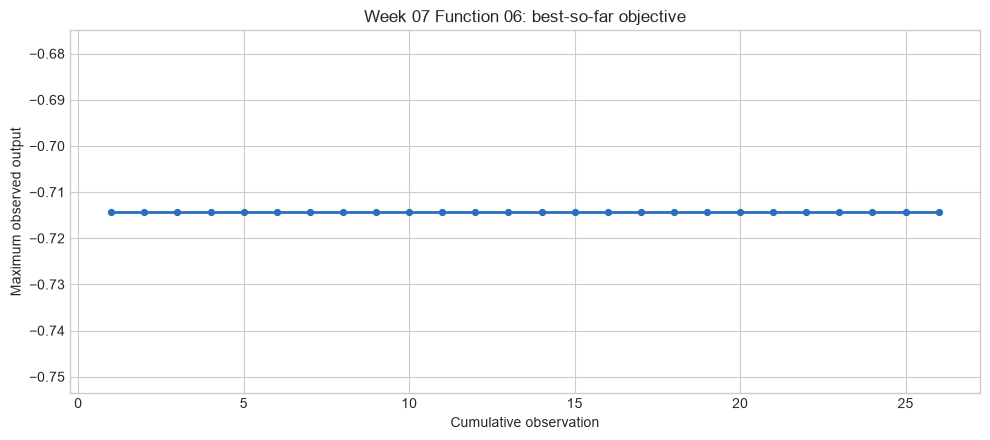

In [67]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [68]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,output
0,1,starter,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265


## 8. Plot the correlation heatmap

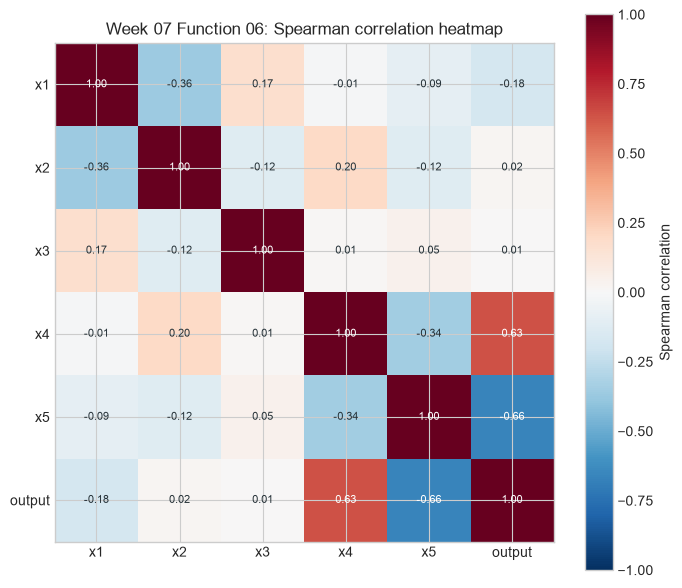

In [69]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

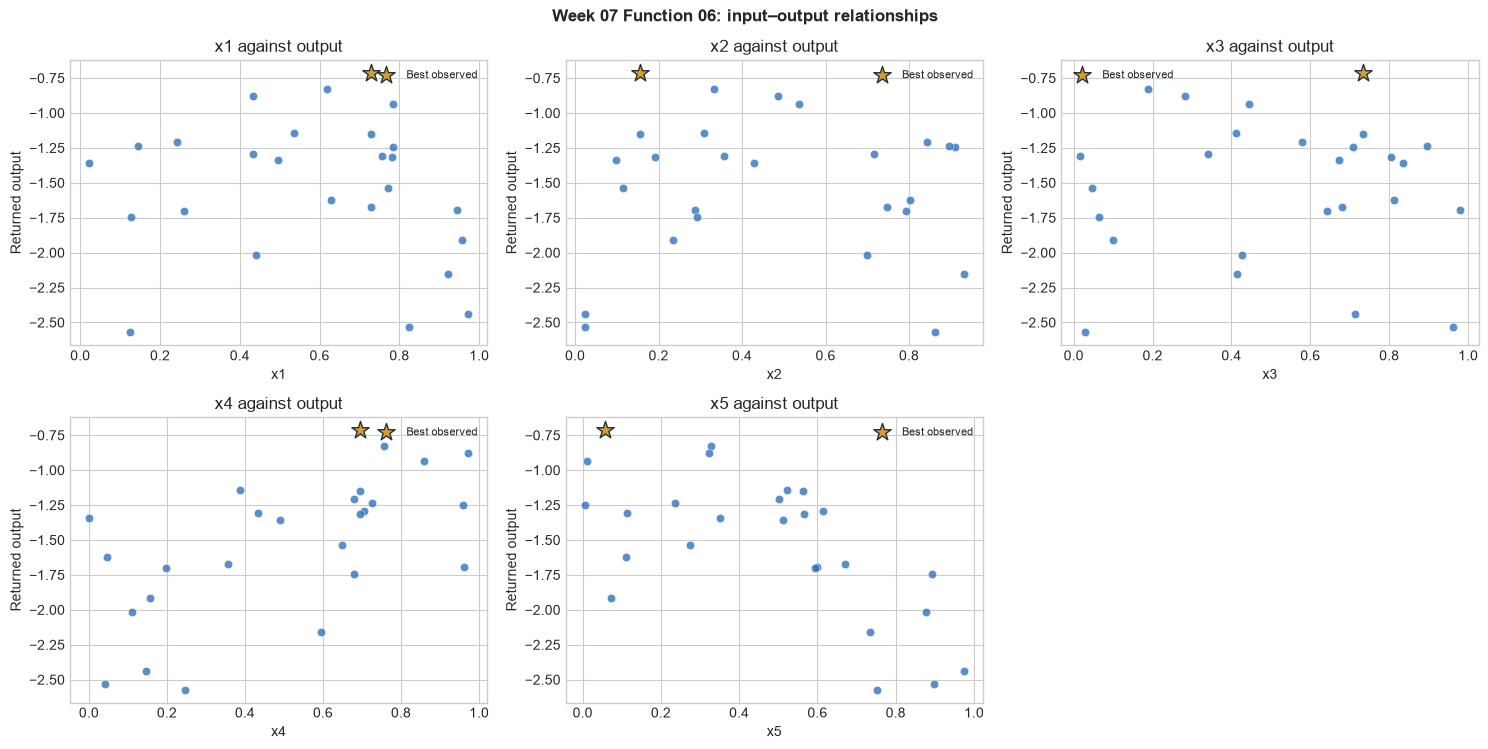

In [70]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [71]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.47**2 * Matern(length_scale=[0.466, 1.15, 1.23, 1.29, 1.49], nu=2.5) + WhiteKernel(noise_level=1e-06)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [72]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_6:0.507243-0.231254-0.979999-0.962525-0.010773


,week,function,kappa,x1,x2,x3,x4,x5,predicted_mean,predicted_std,ucb_score,status
0,7,6,2.0,0.507243,0.231254,0.979999,0.962525,0.010773,-0.460255,0.307192,0.15413,proposed_not_evaluated


# Function 7

Function 7 uses the verified evidence available before Week 07.

In [73]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 7, 7, 6, 6
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [74]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,output
observation,,,,,,,,
26,starter,0.932466,0.488812,0.258608,0.956243,0.190428,0.519852,0.003777
27,starter,0.846867,0.142429,0.060669,0.756292,0.552398,0.081306,0.003134
28,starter,0.806282,0.324122,0.726076,0.148712,0.719376,0.362884,0.021343
29,starter,0.476823,0.340942,0.014335,0.880140,0.998655,0.079664,0.095411
30,week_01,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,1.051015
31,week_02,0.243848,0.900100,0.696978,0.193630,0.374149,0.826324,0.308765
32,week_03,0.143585,0.302559,0.571101,0.194533,0.395561,0.815792,2.149905
33,week_04,0.045103,0.016167,0.773003,0.156031,0.147073,0.616114,1.208733
34,week_05,0.025337,0.910075,0.727790,0.075231,0.386516,0.492629,0.190783


## 2. Extract the function

In [75]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 7: 6 input dimensions, 36 verified observations


## 3. Check shapes and missing values

In [76]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(36, 6)"
1,output shape,"(36,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [77]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,36.0,0.440872,0.320605,0.025337,0.137405,0.447225,0.735944,0.942451
x2,36.0,0.416624,0.268796,0.011813,0.202224,0.427693,0.564890,0.924694
x3,36.0,0.421278,0.303147,0.003635,0.125386,0.369859,0.704253,0.924571
x4,36.0,0.453235,0.315143,0.073659,0.187864,0.339056,0.769030,0.961017
x5,36.0,0.447826,0.292421,0.014944,0.191255,0.404596,0.698286,0.998655
x6,36.0,0.512466,0.258853,0.051100,0.347105,0.600675,0.716003,0.951014
output,36.0,0.364149,0.516290,0.002701,0.020559,0.097959,0.528031,2.149905


## 5. Plot the output trend

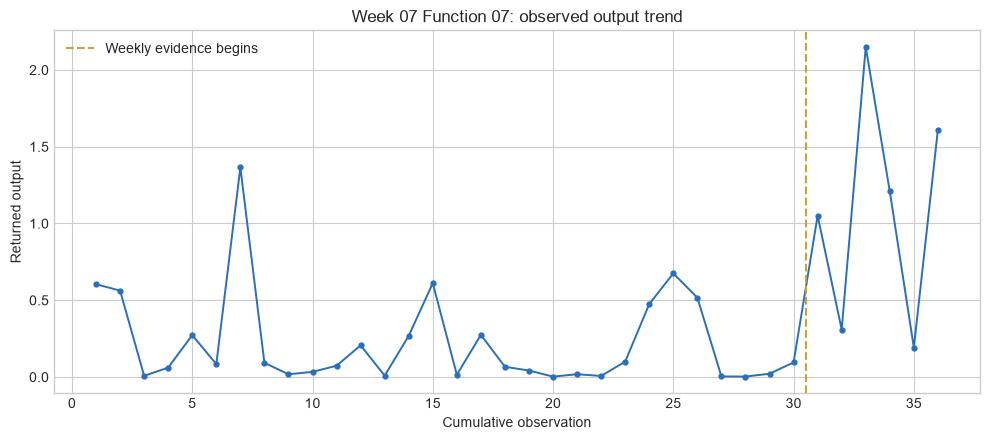

In [78]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

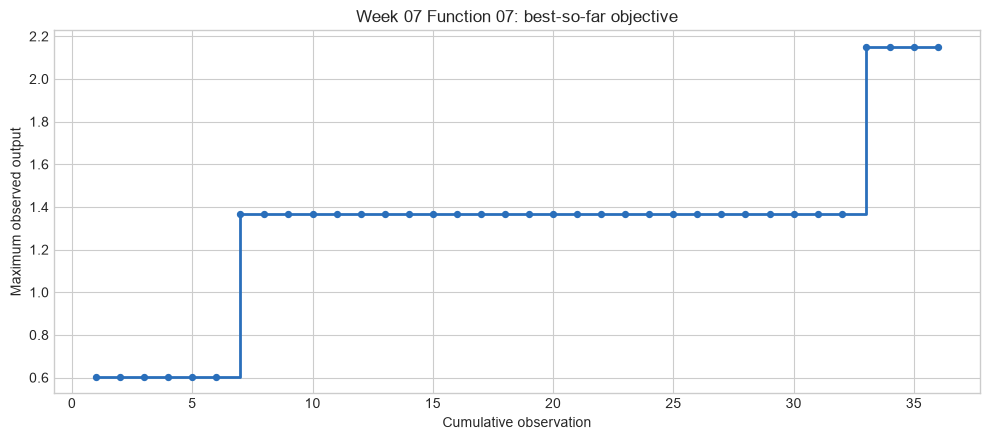

In [79]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [80]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,output
0,33,week_03,0.143585,0.302559,0.571101,0.194533,0.395561,0.815792,2.149905


## 8. Plot the correlation heatmap

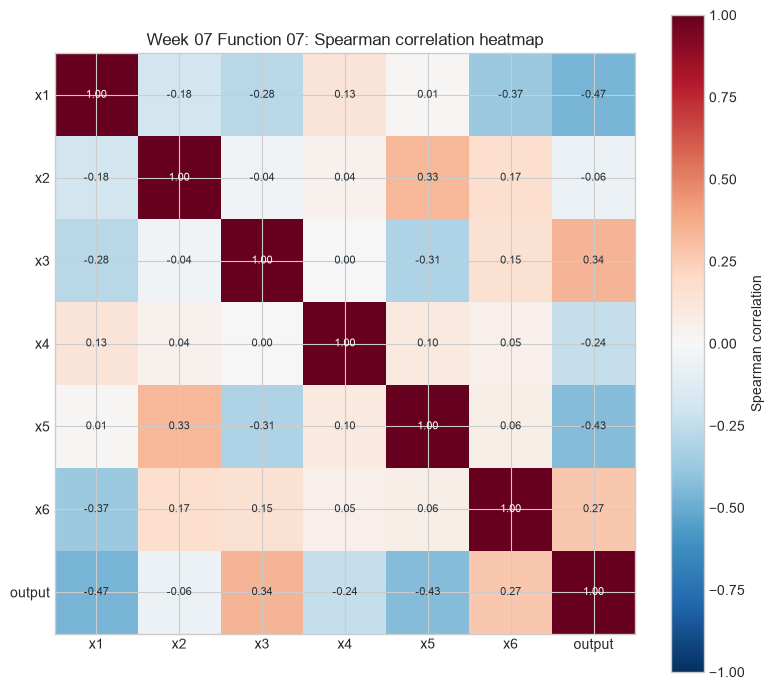

In [81]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

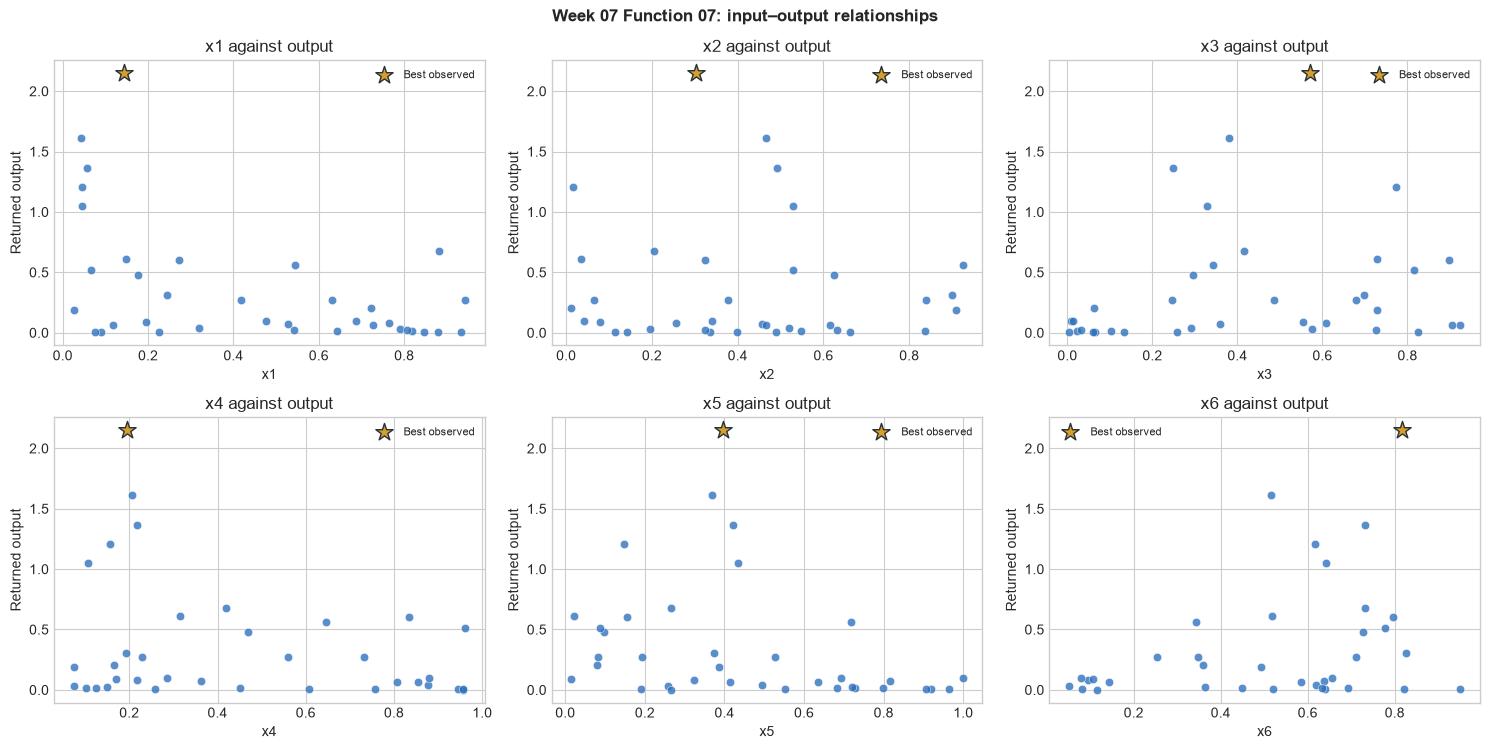

In [82]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [83]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.965**2 * Matern(length_scale=[0.754, 0.367, 10, 0.596, 0.283, 0.76], nu=2.5) + WhiteKernel(noise_level=1.36e-08)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [84]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_7:0.090930-0.302088-0.849894-0.028836-0.252150-0.824777


,week,function,kappa,x1,x2,x3,x4,x5,x6,predicted_mean,predicted_std,ucb_score,status
0,7,7,2.0,0.09093,0.302088,0.849894,0.028836,0.25215,0.824777,1.9306,0.251769,2.434137,proposed_not_evaluated


# Function 8

Function 8 uses the verified evidence available before Week 07.

In [85]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 7, 8, 8, 6
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [86]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,x7,x8,output
observation,,,,,,,,,,
36,starter,0.856007,0.638894,0.326192,0.668503,0.240298,0.210299,0.167546,0.963590,7.977685
37,starter,0.810032,0.635046,0.269548,0.869605,0.661922,0.252259,0.765670,0.890549,7.460872
38,starter,0.796253,0.007037,0.355697,0.487566,0.740520,0.706650,0.992914,0.381734,7.436594
39,starter,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005
40,week_01,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.352588,9.815709
41,week_02,0.163160,0.184786,0.152644,0.083802,0.999322,0.544113,0.184124,0.123846,9.939904
42,week_03,0.088894,0.525132,0.030986,0.992538,0.870819,0.217060,0.011239,0.447691,8.963604
43,week_04,0.356502,0.157574,0.172997,0.610561,0.106477,0.260297,0.411421,0.904740,9.254064
44,week_05,0.110992,0.022977,0.255313,0.963757,0.895383,0.716713,0.030436,0.083412,9.138609


## 2. Extract the function

In [87]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 8: 8 input dimensions, 46 verified observations


## 3. Check shapes and missing values

In [88]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(46, 8)"
1,output shape,"(46,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [89]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,46.0,0.488990,0.314809,0.009077,0.176614,0.476658,0.778700,0.985945
x2,46.0,0.453452,0.308328,0.003419,0.172348,0.503188,0.688062,0.973980
x3,46.0,0.476349,0.290295,0.022929,0.256034,0.418842,0.726319,0.998885
x4,46.0,0.434130,0.287086,0.009043,0.155065,0.470111,0.666931,0.992538
x5,46.0,0.498535,0.296616,0.009649,0.242101,0.460440,0.736592,0.999322
x6,46.0,0.463902,0.278084,0.022113,0.244643,0.409715,0.707594,0.990244
x7,46.0,0.527874,0.280746,0.011239,0.284759,0.555537,0.760819,0.992914
x8,46.0,0.488758,0.283851,0.041956,0.293234,0.474430,0.725448,0.988755
output,46.0,8.006085,1.037050,5.592193,7.315029,8.009949,8.827448,9.939904


## 5. Plot the output trend

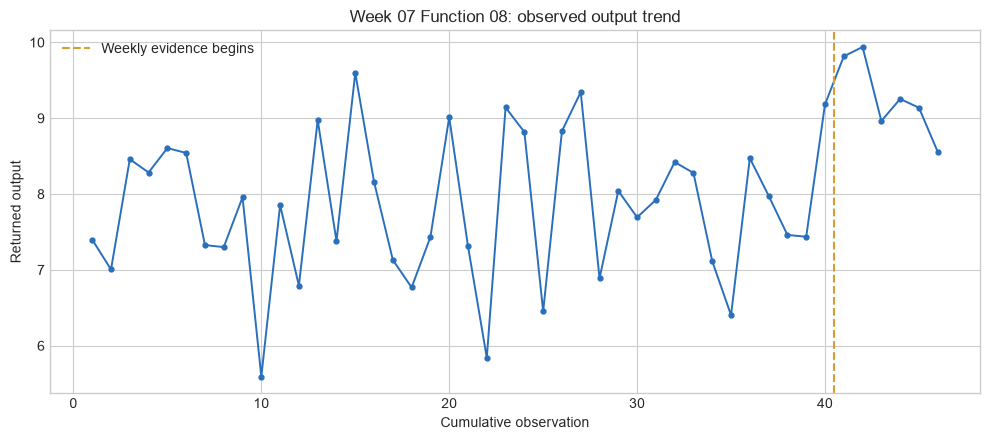

In [90]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

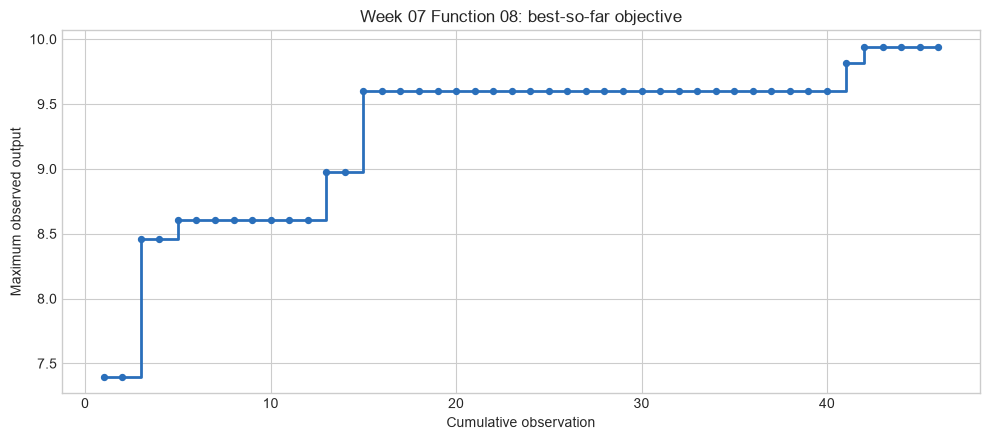

In [91]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [92]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,x7,x8,output
0,42,week_02,0.16316,0.184786,0.152644,0.083802,0.999322,0.544113,0.184124,0.123846,9.939904


## 8. Plot the correlation heatmap

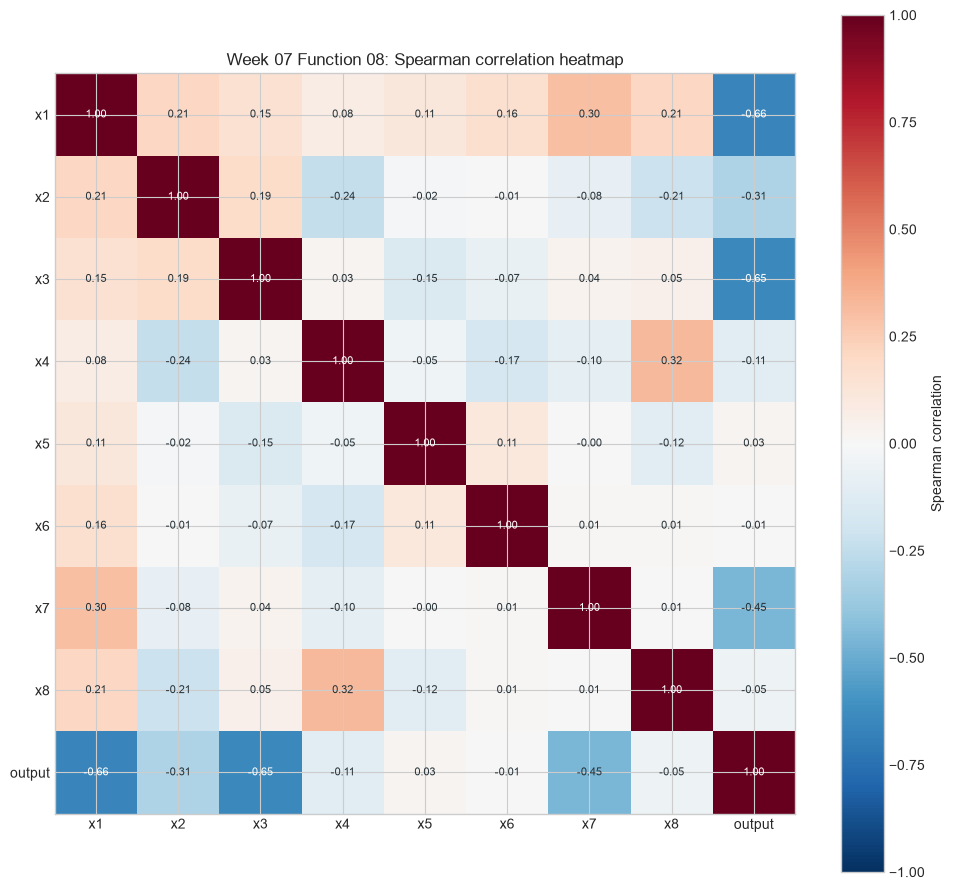

In [93]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

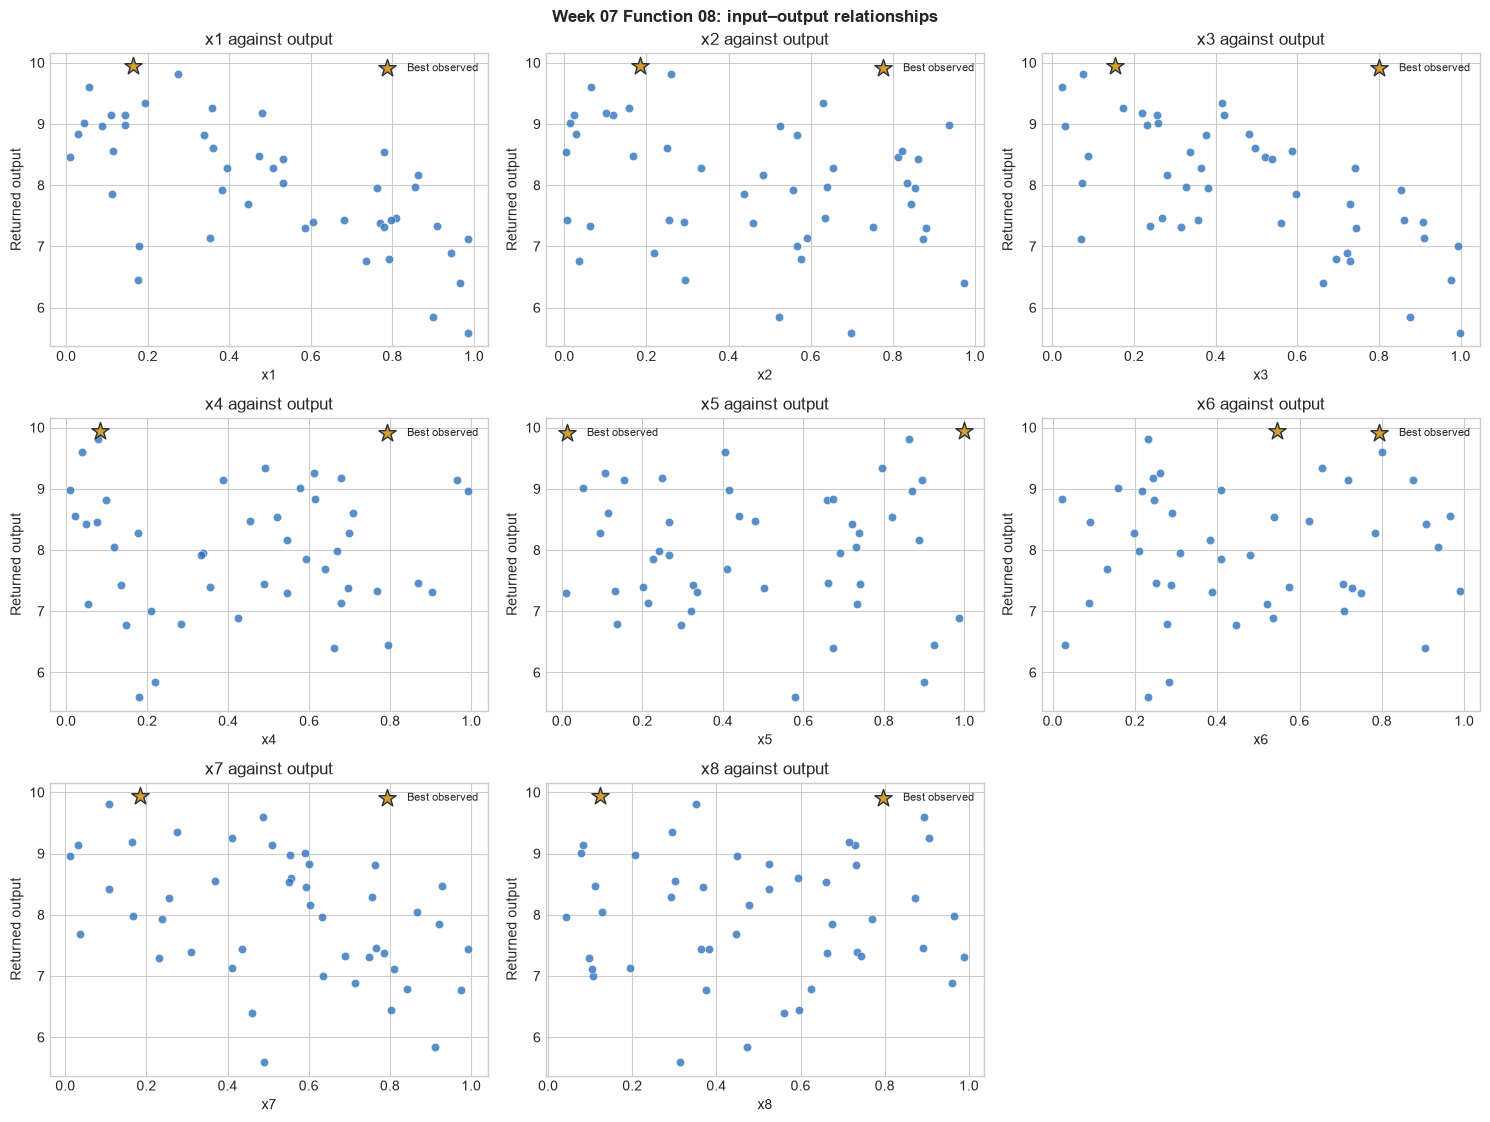

In [94]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [95]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 2.4**2 * Matern(length_scale=[2.14, 3.69, 1.75, 2.93, 10, 10, 2.44, 10], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [96]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_8:0.247503-0.046659-0.126473-0.241238-0.932458-0.825902-0.015877-0.597092


,week,function,kappa,x1,x2,x3,x4,x5,x6,x7,x8,predicted_mean,predicted_std,ucb_score,status
0,7,8,2.0,0.247503,0.046659,0.126473,0.241238,0.932458,0.825902,0.015877,0.597092,9.839947,0.117479,10.074904,proposed_not_evaluated
